# Tarea: Evaluación difusa de riesgo crediticio

## Mario Alejandro Castro Lerma

#### Objetivo

Construir y analizar un sistema de inferencia difusa para estimar el **riesgo crediticio**, utilizando datos reales del dataset  
**German Credit Dataset** (UCI Machine Learning Repository).

El dataset contiene información de solicitantes de crédito, incluyendo:

- duración del crédito  
- monto del préstamo  
- historial crediticio  
- empleo  
- nivel de ahorro  
- estado personal  

Variable objetivo: **Riesgo**

#### Tareas:

- Elegir al menos 3–4 variables relevantes y preprocesarlas para los algoritmos (normalización, discretización, limpieza, etc).
- Definir etiquetas lingüísticas apropiadas para cada variable. 
- Diseñar 6–10 reglas; Justificar cada regla.
- Implementar y comparar los modelos vistos en clase. **Reto Bonus:** explorar otras variantes de FIS.
- Discutir resultados. 

#### Entregables

- Notebook reproducible  
- Visualización de funciones de membresía  
- Tabla comparativa (modelos vs métricas)  
- Discusión técnica  

#### Preparando Dataset

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

In [103]:
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

df = pd.read_csv(URL, sep=' ', header=None)

# Target
df['risk'] = df[20]

df.drop(columns=[20], inplace=True)

print(df.shape)
df.head()

(1000, 21)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1000 non-null   str  
 1   1       1000 non-null   int64
 2   2       1000 non-null   str  
 3   3       1000 non-null   str  
 4   4       1000 non-null   int64
 5   5       1000 non-null   str  
 6   6       1000 non-null   str  
 7   7       1000 non-null   int64
 8   8       1000 non-null   str  
 9   9       1000 non-null   str  
 10  10      1000 non-null   int64
 11  11      1000 non-null   str  
 12  12      1000 non-null   int64
 13  13      1000 non-null   str  
 14  14      1000 non-null   str  
 15  15      1000 non-null   int64
 16  16      1000 non-null   str  
 17  17      1000 non-null   int64
 18  18      1000 non-null   str  
 19  19      1000 non-null   str  
 20  risk    1000 non-null   int64
dtypes: int64(8), str(13)
memory usage: 209.1 KB


In [105]:
df['risk'].value_counts()

risk
1    700
2    300
Name: count, dtype: int64

In [106]:
df['risk'] = df['risk'].map({
    1 : 'bajo',
    2 : 'alto'
})

df['risk'].value_counts()

risk
bajo    700
alto    300
Name: count, dtype: int64

0 = bajo riesgo (es decir bueno)
1 = alto riesgo (es decir malo)

#### Seleccion de columnas:

In [107]:
selected_cols = [
    'duration',
    'credit_history',
    'purpose',
    'credit_amount',
    'risk'
]

credit_df = df[[1, 2, 3, 4, 'risk']].copy()

credit_df.columns = selected_cols

credit_df.head()

,duration,credit_history,purpose,credit_amount,risk
0,6,A34,A43,1169,bajo
1,48,A32,A43,5951,alto
2,12,A34,A46,2096,bajo
3,42,A32,A42,7882,bajo
4,24,A33,A40,4870,alto


In [108]:
credit_df.describe()

,duration,credit_amount
count,1000.000000,1000.000000
mean,20.903000,3271.258000
std,12.058814,2822.736876
min,4.000000,250.000000
25%,12.000000,1365.500000
50%,18.000000,2319.500000
75%,24.000000,3972.250000
max,72.000000,18424.000000


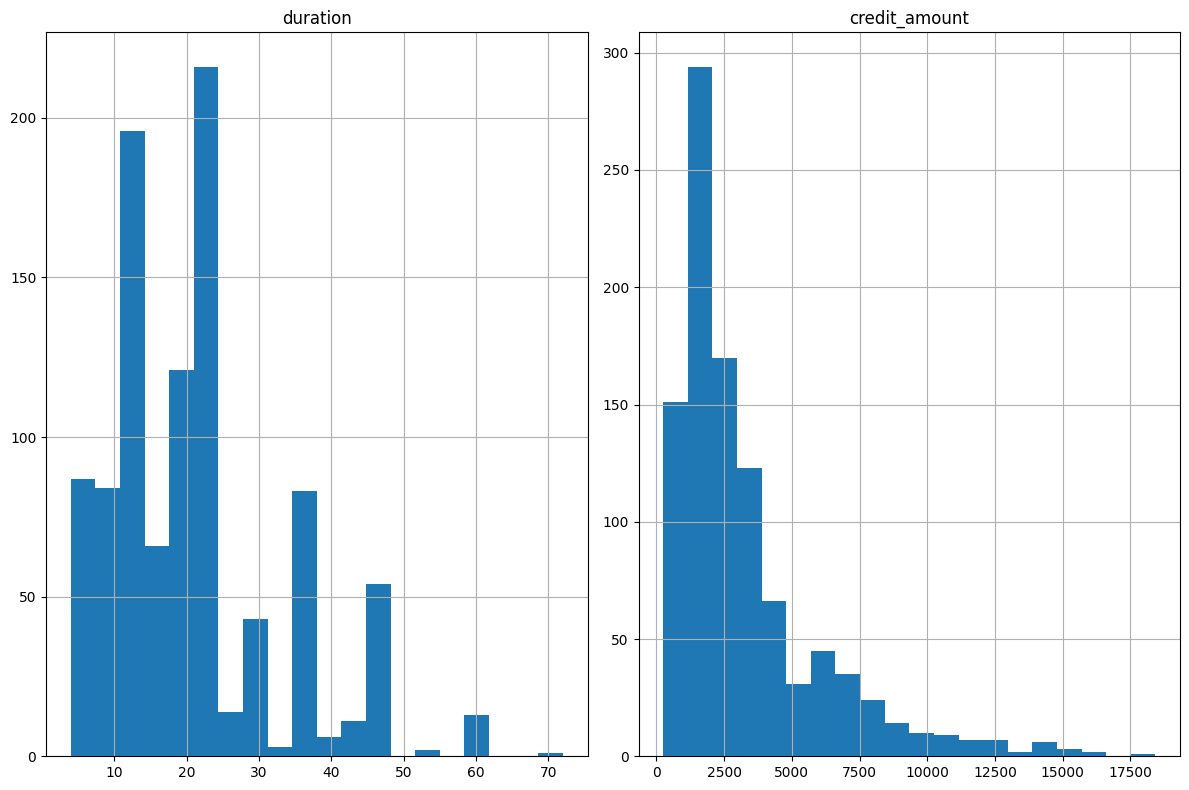

In [109]:

credit_df.hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

Voy a renombrar las etiquetas para poder entenderlas mejor:

In [110]:
credit_history_map = {
    'A30': 'no_credits_all_paid',
    'A31': 'all_paid_bank',
    'A32': 'current_paid',
    'A33': 'past_delay',
    'A34': 'critical_account'
}

purpose_map = {
    'A40': 'new_car',
    'A41': 'used_car',
    'A42': 'furniture_equipment',
    'A43': 'radio_tv',
    'A44': 'domestic_appliances',
    'A45': 'repairs',
    'A46': 'education',
    'A47': 'vacation',
    'A48': 'retraining',
    'A49': 'business',
    'A410': 'others'
}
credit_df['credit_history'] = (
    credit_df['credit_history']
    .map(credit_history_map)
)

credit_df['purpose'] = (
    credit_df['purpose']
    .map(purpose_map)
)

credit_df.head()

,duration,credit_history,purpose,credit_amount,risk
0,6,critical_account,radio_tv,1169,bajo
1,48,current_paid,radio_tv,5951,alto
2,12,critical_account,education,2096,bajo
3,42,current_paid,furniture_equipment,7882,bajo
4,24,past_delay,new_car,4870,alto


In [111]:
print(credit_df['credit_history'].value_counts())
print()

print(credit_df['purpose'].value_counts())

credit_history
current_paid           530
critical_account       293
past_delay              88
all_paid_bank           49
no_credits_all_paid     40
Name: count, dtype: int64

purpose
radio_tv               280
new_car                234
furniture_equipment    181
used_car               103
business                97
education               50
repairs                 22
domestic_appliances     12
others                  12
retraining               9
Name: count, dtype: int64


### Creando etiquetas para modelarlo:

Primero categoricas:

In [112]:
purpose_group_map = {
    'new_car': 'vehiculo',
    'used_car': 'vehiculo',

    'furniture_equipment': 'hogar',
    'radio_tv': 'hogar',
    'domestic_appliances': 'hogar',
    'repairs': 'hogar',

    'education': 'educacion',
    'retraining': 'educacion',

    'business': 'negocio',

    'others': 'otros'
}
credit_df['purpose_group'] = (
    credit_df['purpose']
    .map(purpose_group_map)
)

credit_df['purpose_group'].value_counts()

purpose_group
hogar        495
vehiculo     337
negocio       97
educacion     59
otros         12
Name: count, dtype: int64

In [113]:
history_linguistic_map = {
    'no_credits_all_paid': 'excelente',
    'all_paid_bank': 'bueno',
    'current_paid': 'estable',
    'past_delay': 'riesgoso',
    'critical_account': 'critico'
}

credit_df['history_label'] = (
    credit_df['credit_history']
    .map(history_linguistic_map)
)
credit_df['history_label'].value_counts()

history_label
estable      530
critico      293
riesgoso      88
bueno         49
excelente     40
Name: count, dtype: int64

Ahora las numericas:

In [114]:
credit_df[['duration', 'credit_amount']].describe()

,duration,credit_amount
count,1000.000000,1000.000000
mean,20.903000,3271.258000
std,12.058814,2822.736876
min,4.000000,250.000000
25%,12.000000,1365.500000
50%,18.000000,2319.500000
75%,24.000000,3972.250000
max,72.000000,18424.000000


Voy a categorizarlo por quartiles

In [115]:
# =========================
# Duration
# =========================

duration_bins = [0, 12, 24, 100]
duration_labels = ['corto', 'medio', 'largo']

credit_df['duration_label'] = pd.cut(
    credit_df['duration'],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)

# =========================
# Credit Amount
# =========================

amount_bins = [0, 1365, 3973, 20000]
amount_labels = ['bajo', 'medio', 'alto']

credit_df['amount_label'] = pd.cut(
    credit_df['credit_amount'],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True
)

# Ver resultados
credit_df.head()

,duration,credit_history,purpose,credit_amount,risk,purpose_group,history_label,duration_label,amount_label
0,6,critical_account,radio_tv,1169,bajo,hogar,critico,corto,bajo
1,48,current_paid,radio_tv,5951,alto,hogar,estable,largo,alto
2,12,critical_account,education,2096,bajo,educacion,critico,corto,medio
3,42,current_paid,furniture_equipment,7882,bajo,hogar,estable,largo,alto
4,24,past_delay,new_car,4870,alto,vehiculo,riesgoso,medio,alto


In [116]:
print(credit_df['duration_label'].value_counts())
print()

print(credit_df['amount_label'].value_counts())

duration_label
medio    411
corto    359
largo    230
Name: count, dtype: int64

amount_label
medio    501
bajo     250
alto     249
Name: count, dtype: int64


| Variable         | Tipo original | Valor/Código original      | Significado                  | Etiqueta |
| ---------------- | ------------- | -------------------------- | ------------------------------------------ | ----------------------------- |
| `duration`       | Numérica      | 0 – 12 meses               | Crédito corto                              | `corto`                       |
| `duration`       | Numérica      | 12 – 24 meses              | Crédito medio                              | `medio`                      |
| `duration`       | Numérica      | 24 – 72 meses              | Crédito largo                              | `largo`                        |
| `credit_amount`  | Numérica      | 0 – 1365                   | Monto bajo                                 | `bajo`                         |
| `credit_amount`  | Numérica      | 1365 – 3972                | Monto medio                                | `medio`                      |
| `credit_amount`  | Numérica      | 3972 – 18424               | Monto alto                                 | `alto`                        |
| `credit_history` | Categórica    | `A30`                      | Sin créditos / todos pagados               | `excelente`                   |
| `credit_history` | Categórica    | `A31`                      | Todos pagados en este banco                | `bueno`                        |
| `credit_history` | Categórica    | `A32`                      | Créditos actuales pagados correctamente    | `estable`                      |
| `credit_history` | Categórica    | `A33`                      | Retrasos de pago previos                   | `riesgoso`                       |
| `credit_history` | Categórica    | `A34`                      | Cuenta crítica / otros créditos existentes | `critico`                    |
| `purpose`        | Categórica    | `A40`, `A41`               | Vehículos                                  | `vehiculo`                     |
| `purpose`        | Categórica    | `A42`, `A43`, `A44`, `A45` | Hogar/equipamiento/reparaciones            | `casa`                        |
| `purpose`        | Categórica    | `A46`, `A48`               | Educación/reentrenamiento                  | `educacion`                   |
| `purpose`        | Categórica    | `A49`                      | Negocio                                    | `negocio`                    |
| `purpose`        | Categórica    | `A47`, `A410`              | Otros propósitos                           | `otro`                       |
| `risk`           | Objetivo      | `1`                        | Bajo riesgo crediticio                     | `bueno`                    |
| `risk`           | Objetivo      | `2`                        | Alto riesgo crediticio                     | `malo`                   |


### Diseño de reglas:

| Regla                                                                                   | Resultado de Riesgo | Justificación                                                                                                                                                 |
| --------------------------------------------------------------------------------------- | ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|1.  IF `credit_history` IS `riesgoso` AND `duration` IS `largo`           | Alto                | Los antecedentes de retrasos en pagos y los créditos de larga duración incrementan la incertidumbre de recuperación del préstamo.                             |
|2.  IF `credit_history` IS `excelente` AND `duration` IS `corto`       | Bajo                | Un cliente con excelente historial y un crédito de corta duración presenta bajo nivel de exposición financiera.                                               |
|3.  IF `credit_amount` IS `bajo` AND `duration` IS `corto`              | Bajo                | Los préstamos pequeños y de corto plazo suelen ser más fáciles de liquidar y representan menor riesgo crediticio.                                             |
|4.  IF `purpose` IS `negocio` AND `credit_amount` IS `alto`           | Alto                | Los préstamos empresariales de alto monto poseen mayor volatilidad y riesgo económico.                                                                        |
|5.  IF `purpose` IS `educacion` AND `credit_history` IS `bueno`          | Bajo                | Los créditos educativos, junto con un historial positivo, tienden a asociarse con perfiles financieros más estables.                                          |
|6.  IF `credit_history` IS `estable` AND `credit_amount` IS `medio`  | Medio               | Un historial estable reduce el riesgo, aunque un monto moderado todavía implica cierta incertidumbre financiera.                                              |
|7.  IF `duration` IS `largo` AND `credit_amount` IS `alto`              | Alto                | Los créditos de gran monto y larga duración incrementan significativamente el compromiso financiero del solicitante.                                          |
|8.  IF `purpose` IS `hogar` AND `credit_history` IS `excelente`          | Bajo                | Los préstamos relacionados con vivienda o equipamiento suelen ser más estables cuando el solicitante posee buen historial crediticio.                         |
|9.  IF `credit_history` IS `critico` OR `riesgoso`                                 | Alto                | El historial crediticio es uno de los principales indicadores de riesgo; un estado crítico es suficiente para considerar alta probabilidad de incumplimiento. |


### Implementando Modelos

Funciones de membresia:

In [117]:
def triangular(x, a, b, c):
    if x <= a or x >= c:
        return 0

    elif a < x < b:
        return (x - a) / (b - a)

    elif b <= x < c:
        return (c - x) / (c - b)

    return 0


def trapezoidal(x, a, b, c, d):
    if x <= a or x >= d:
        return 0

    elif b <= x <= c:
        return 1

    elif a < x < b:
        return (x - a) / (b - a)

    elif c < x < d:
        return (d - x) / (d - c)

    return 0

In [131]:
def fuzzify_duration(x):

    return {
        "corto": trapezoidal(x, 0, 0, 12, 18),

        "medio": triangular(x, 12, 23, 36),

        "largo": trapezoidal(x, 24, 36, 72, 72)
    }
def fuzzify_amount(x):

    return {
        "bajo": trapezoidal(x, 0, 0, 1500, 2500),

        "medio": triangular(x, 1500, 4000, 6500),

        "alto": trapezoidal(x, 4000, 7000, 20000, 20000)
    }
    
def fuzzify_history(history):

    semantic = history_linguistic_map[history]

    labels = [
        "excelente",
        "bueno",
        "estable",
        "riesgoso",
        "critico"
    ]

    return {
        label: 1 if label == semantic else 0
        for label in labels
    }


def fuzzify_purpose(purpose):

    semantic = purpose_group_map[purpose]

    labels = [
        "hogar",
        "educacion",
        "vehiculo",
        "negocio",
        "otros"
    ]

    return {
        label: 1 if label == semantic else 0
        for label in labels
    }

#### Mamdani:

In [ ]:
def mamdani(client):

    duration = fuzzify_duration(
        client["duration"]
    )

    amount = fuzzify_amount(
        client["amount"]
    )

    history = fuzzify_history(
        client["history"]
    )

    purpose = fuzzify_purpose(
        client["purpose"]
    )

    rules = []

    # =========================
    # REGLA 1
    # IF history IS critica OR riesgoso
    # THEN risk IS alto
    # =========================

    activation = max(
        history["critico"],
        history["riesgoso"]
    )

    rules.append(
        (activation, 75)
    )

    # =========================
    # REGLA 2
    # IF history IS riesgosa
    # AND duration IS largo
    # THEN risk IS alto
    # =========================

    activation = min(
        history["riesgoso"],
        duration["largo"]
    )

    rules.append(
        (activation, 75)
    )

    # =========================
    # REGLA 3
    # IF history IS excelente
    # AND duration IS corto
    # THEN risk IS bajo
    # =========================

    activation = min(
        history["excelente"],
        duration["corto"]
    )

    rules.append(
        (activation, 25)
    )

    # =========================
    # REGLA 4
    # IF amount IS bajo
    # AND duration IS corta
    # THEN risk IS bajo
    # =========================

    activation = min(
        amount["bajo"],
        duration["corto"]
    )

    rules.append(
        (activation, 25)
    )

    # =========================
    # REGLA 5
    # IF purpose IS negocio
    # AND amount IS alto
    # THEN risk IS alto
    # =========================

    activation = min(
        purpose["negocio"],
        amount["alto"]
    )

    rules.append(
        (activation, 75)
    )

    # =========================
    # REGLA 6
    # IF purpose IS educacion
    # AND history IS buena
    # THEN risk IS bajo
    # =========================

    activation = min(
        purpose["educacion"],
        history["bueno"]
    )

    rules.append(
        (activation, 25)
    )

    # =========================
    # REGLA 7
    # IF history IS estable
    # AND amount IS medio
    # THEN risk IS medio
    # =========================

    activation = min(
        history["estable"],
        amount["medio"]
    )

    rules.append(
        (activation, 50)
    )

    # =========================
    # REGLA 8
    # IF duration IS largo
    # AND amount IS alto
    # THEN risk IS alto
    # =========================

    activation = min(
        duration["largo"],
        amount["alto"]
    )

    rules.append(
        (activation, 75)
    )

    # =========================
    # REGLA 9
    # IF purpose IS hogar
    # AND history IS excelente
    # THEN risk IS bajo
    # =========================

    activation = min(
        purpose["hogar"],
        history["excelente"]
    )

    rules.append(
        (activation, 25)
    )

    # =========================
    # DEFUZZIFICACION
    # =========================

    numerator = sum(
        activation * value
        for activation, value in rules
    )

    denominator = sum(
        activation
        for activation, value in rules
    )

    if denominator == 0:
        return 0

    risk = numerator / denominator

    return risk


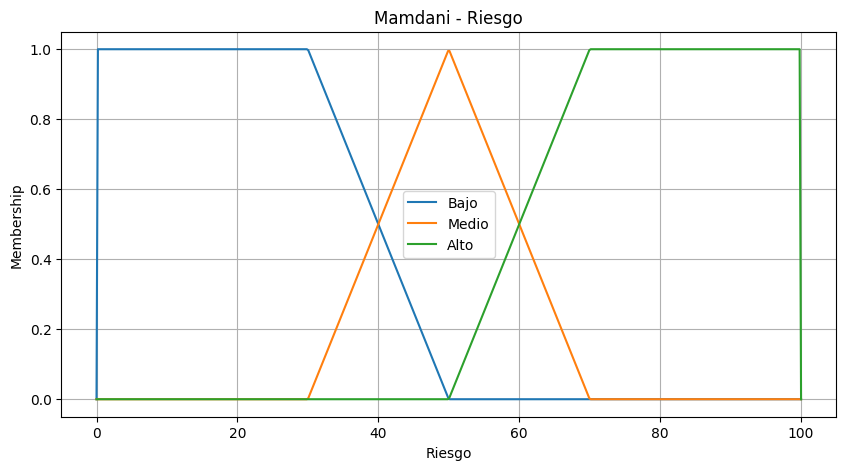

In [203]:
x = np.linspace(0, 100, 500)

riesgo_bajo = [
    trapezoidal(v, 0, 0, 30, 50)
    for v in x
]

riesgo_medio = [
    triangular(v, 30, 50, 70)
    for v in x
]

riesgo_alto = [
    trapezoidal(v, 50, 70, 100, 100)
    for v in x
]

plt.figure(figsize=(10, 5))

plt.plot(x, riesgo_bajo, label="Bajo")
plt.plot(x, riesgo_medio, label="Medio") # En el resultado final no existe "medio" pero para que se vea bien la grafica lo deje
plt.plot(x, riesgo_alto, label="Alto")

plt.title("Mamdani - Riesgo")
plt.xlabel("Riesgo")
plt.ylabel("Membership")

plt.legend()
plt.grid()

plt.show()

#### Takagi-Sugeno

In [181]:
def sugeno(client):

    duration = fuzzify_duration(
        client["duration"]
    )

    amount = fuzzify_amount(
        client["amount"]
    )

    history = fuzzify_history(
        client["history"]
    )

    purpose = fuzzify_purpose(
        client["purpose"]
    )

    rules = []

    # =========================
    # REGLA 1
    # IF history IS critico OR riesgoso
    # THEN risk = 90
    # =========================

    w = max(
        history["critico"],
        history["riesgoso"]
    )
    z = 90

    rules.append((w, z))

    # =========================
    # REGLA 2
    # IF history IS riesgoso
    # AND duration IS larga
    # THEN risk = 80
    # =========================

    w = min(
        history["riesgoso"],
        duration["largo"]
    )

    z = 80

    rules.append((w, z))

    # =========================
    # REGLA 3
    # IF history IS excelente
    # AND duration IS corta
    # THEN risk = 20
    # =========================

    w = min(
        history["excelente"],
        duration["corto"]
    )

    z = 20

    rules.append((w, z))

    # =========================
    # REGLA 4
    # IF amount IS bajo
    # AND duration IS corta
    # THEN risk = 25
    # =========================

    w = min(
        amount["bajo"],
        duration["corto"]
    )

    z = 25

    rules.append((w, z))

    # =========================
    # REGLA 5
    # IF purpose IS negocio
    # AND amount IS alto
    # THEN risk = 85
    # =========================

    w = min(
        purpose["negocio"],
        amount["alto"]
    )

    z = 85

    rules.append((w, z))

    # =========================
    # REGLA 6
    # IF purpose IS educacion
    # AND history IS bueno
    # THEN risk = 30
    # =========================

    w = min(
        purpose["educacion"],
        history["bueno"]
    )

    z = 30

    rules.append((w, z))

    # =========================
    # REGLA 7
    # IF history IS estable
    # AND amount IS medio
    # THEN risk = 50
    # =========================

    w = min(
        history["estable"],
        amount["medio"]
    )

    z = 50

    rules.append((w, z))

    # =========================
    # REGLA 8
    # IF duration IS larga
    # AND amount IS alto
    # THEN risk = 85
    # =========================

    w = min(
        duration["largo"],
        amount["alto"]
    )

    z = 85

    rules.append((w, z))

    # =========================
    # REGLA 9
    # IF purpose IS hogar
    # AND history IS excelente
    # THEN risk = 20
    # =========================

    w = min(
        purpose["hogar"],
        history["excelente"]
    )

    z = 20

    rules.append((w, z))

    # =========================
    # AGREGACION SUGENO
    # =========================

    numerator = sum(
        w * z
        for w, z in rules
    )

    denominator = sum(
        w
        for w, z in rules
    )

    if denominator == 0:
        
        return 0
    
    return numerator / denominator

#### Tsukamoto 

In [182]:
def risk_high_inverse(w):

    # Membership creciente:
    # 50 -> 0
    # 100 -> 1

    return 50 + (w * 50)
def risk_low_inverse(w):

    # Membership decreciente:
    # 0 -> 1
    # 50 -> 0

    return 50 - (w * 50)
def risk_medium_inverse(w):

    return 50
def tsukamoto(client):

    duration = fuzzify_duration(
        client["duration"]
    )

    amount = fuzzify_amount(
        client["amount"]
    )

    history = fuzzify_history(
        client["history"]
    )

    purpose = fuzzify_purpose(
        client["purpose"]
    )

    rules = []

    # ==================================================
    # REGLA 1
    # IF history IS critico
    # OR history IS riesgoso
    # THEN risk IS alto
    # ==================================================

    w = max(
        history["critico"],
        history["riesgoso"]
    )

    z = risk_high_inverse(w)

    rules.append((w, z))

    # ==================================================
    # REGLA 2
    # IF history IS excelente
    # AND duration IS corto
    # THEN risk IS bajo
    # ==================================================

    w = min(
        history["excelente"],
        duration["corto"]
    )

    z = risk_low_inverse(w)

    rules.append((w, z))

    # ==================================================
    # REGLA 3
    # IF amount IS bajo
    # AND duration IS corto
    # THEN risk IS bajo
    # ==================================================

    w = min(
        amount["bajo"],
        duration["corto"]
    )

    z = risk_low_inverse(w)

    rules.append((w, z))

    # ==================================================
    # REGLA 4
    # IF purpose IS negocio
    # AND amount IS alto
    # THEN risk IS alto
    # ==================================================

    w = min(
        purpose["negocio"],
        amount["alto"]
    )

    z = risk_high_inverse(w)

    rules.append((w, z))

    # ==================================================
    # REGLA 5
    # IF purpose IS educacion
    # AND history IS bueno
    # THEN risk IS bajo
    # ==================================================

    w = min(
        purpose["educacion"],
        history["bueno"]
    )

    z = risk_low_inverse(w)

    rules.append((w, z))

    # ==================================================
    # REGLA 6
    # IF history IS estable
    # AND amount IS medio
    # THEN risk IS medio
    # ==================================================

    w = min(
        history["estable"],
        amount["medio"]
    )

    z = risk_medium_inverse(w)

    rules.append((w, z))

    # ==================================================
    # REGLA 7
    # IF duration IS largo
    # AND amount IS alto
    # THEN risk IS alto
    # ==================================================

    w = min(
        duration["largo"],
        amount["alto"]
    )

    z = risk_high_inverse(w)

    rules.append((w, z))

    # ==================================================
    # REGLA 8
    # IF purpose IS hogar
    # AND history IS excelente
    # THEN risk IS bajo
    # ==================================================

    w = min(
        purpose["hogar"],
        history["excelente"]
    )

    z = risk_low_inverse(w)

    rules.append((w, z))

    # ==================================================
    # REGLA 9
    # IF amount IS medio
    # AND duration IS medio
    # THEN risk IS medio
    # ==================================================

    w = min(
        amount["medio"],
        duration["medio"]
    )

    z = risk_medium_inverse(w)

    rules.append((w, z))

    # ==================================================
    # AGREGACION FINAL
    # ==================================================

    numerator = sum(
        w * z
        for w, z in rules
    )

    denominator = sum(
        w
        for w, z in rules
    )

    if denominator == 0:
        return 0

    return numerator / denominator

### Prueba con clientes del dataset:

In [183]:
client_1 = {
    "duration": 6,
    "amount": 1169,
    "history": "critical_account",
    "purpose": "radio_tv"
}	

client_2 = {
    "duration": 48,
    "amount": 5951,
    "history": "current_paid",
    "purpose": "radio_tv"
}

client_3 = {
    "duration": 24,
    "amount": 4870,
    "history": "past_delay",
    "purpose": "new_car"
}


Mamdani:

In [184]:

print(mamdani(client_1), " Etiqueta real: bajo")
print(mamdani(client_2), " Etiqueta real: alto")
print(mamdani(client_3), " Etiqueta real: alto")

50.0  Etiqueta real: bajo
68.68917158402942  Etiqueta real: alto
75.0  Etiqueta real: alto


Takagi-Sugeno

In [185]:
print(sugeno(client_1), " Etiqueta real: bajo")
print(sugeno(client_2), " Etiqueta real: alto")
print(sugeno(client_3), " Etiqueta real: alto")

57.5  Etiqueta real: bajo
76.16484021764118  Etiqueta real: alto
90.0  Etiqueta real: alto


In [186]:
print(tsukamoto(client_1), " Etiqueta real: bajo")
print(tsukamoto(client_2), " Etiqueta real: alto")
print(tsukamoto(client_3), " Etiqueta real: alto")

50.0  Etiqueta real: bajo
74.30838250696094  Etiqueta real: alto
80.26634382566586  Etiqueta real: alto


### Evaluacion:

          Modelo  Accuracy  Precision    Recall        F1
0        Mamdani     0.588   0.328221  0.356667  0.341853
1  Takagi-Sugeno     0.588   0.329268  0.360000  0.343949
2      Tsukamoto     0.558   0.298295  0.350000  0.322086


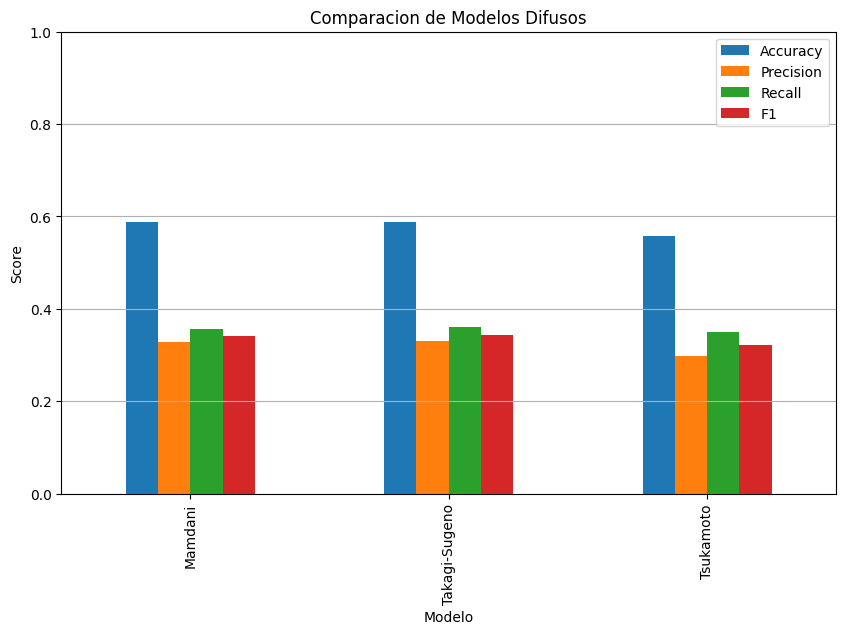

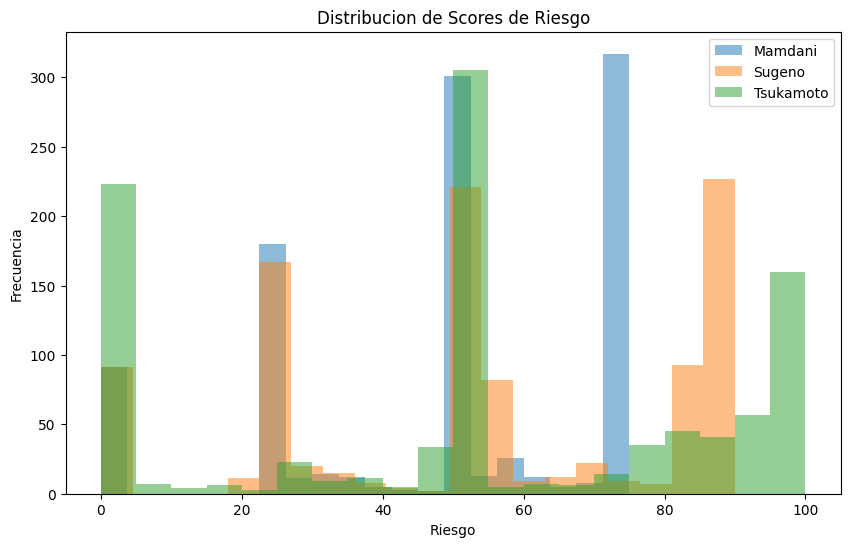

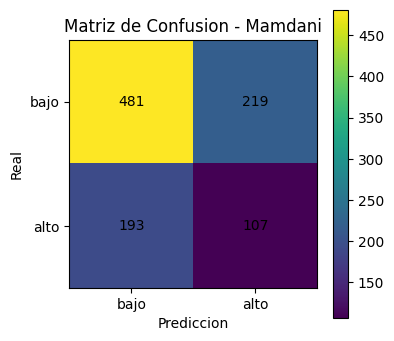

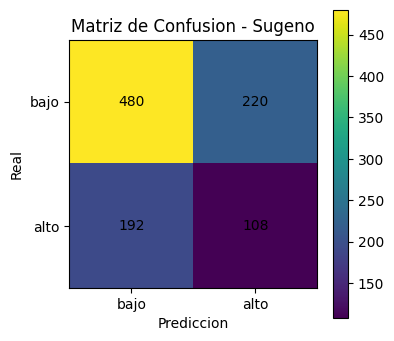

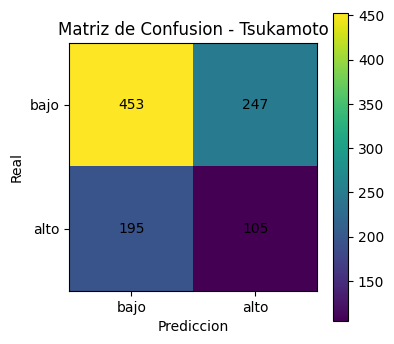

In [205]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# FUNCION AUXILIAR
# ============================================================
# Con esta parte estuve jugando pero no encontre un threshold que resultara bueno asi que lo deje alrededor de en medio.
def risk_to_label(score, model_name):
    
    mamdani_threshold = 65
    sugeno_threshold = 75
    tsukamoto_threshold = 70

    if model_name == "mamdani":
        return "alto" if score >= mamdani_threshold else "bajo"
    elif model_name == "sugeno":
        return "alto" if score >= sugeno_threshold else "bajo"
    elif model_name == "tsukamoto":
        return "alto" if score >= tsukamoto_threshold else "bajo"

    return "bajo"


# ============================================================
# EVALUAR MODELO
# ============================================================

def evaluate_model(model_function, df):

    y_true = []
    y_pred = []

    numeric_scores = []

    for _, row in credit_df.iterrows():

        client = {
            "duration": row["duration"],
            "amount": row["credit_amount"],
            "history": row["credit_history"],
            "purpose": row["purpose"]
        }

        # Prediccion numerica
        score = model_function(client)

        # Convertir a etiqueta
        pred = risk_to_label(score, model_function.__name__)

        # Valores reales
        real = row["risk"]

        y_true.append(real)
        y_pred.append(pred)

        numeric_scores.append(score)

    # ========================================================
    # METRICAS
    # ========================================================

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        pos_label="alto"
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label="alto"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label="alto"
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["bajo", "alto"]
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "scores": numeric_scores,
        "predictions": y_pred
    }


# ============================================================
# EVALUAR LOS 3 MODELOS
# ============================================================

mamdani_results = evaluate_model(
    mamdani,
    credit_df
)

sugeno_results = evaluate_model(
    sugeno,
    credit_df
)

tsukamoto_results = evaluate_model(
    tsukamoto,
    credit_df
)


# ============================================================
# TABLA COMPARATIVA
# ============================================================

comparison_df = pd.DataFrame({

    "Modelo": [
        "Mamdani",
        "Takagi-Sugeno",
        "Tsukamoto"
    ],

    "Accuracy": [
        mamdani_results["accuracy"],
        sugeno_results["accuracy"],
        tsukamoto_results["accuracy"]
    ],

    "Precision": [
        mamdani_results["precision"],
        sugeno_results["precision"],
        tsukamoto_results["precision"]
    ],

    "Recall": [
        mamdani_results["recall"],
        sugeno_results["recall"],
        tsukamoto_results["recall"]
    ],

    "F1": [
        mamdani_results["f1"],
        sugeno_results["f1"],
        tsukamoto_results["f1"]
    ]
})

print(comparison_df)


# ============================================================
# GRAFICA COMPARATIVA
# ============================================================

comparison_df.set_index("Modelo").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparacion de Modelos Difusos")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.grid(axis="y")
plt.show()


# ============================================================
# VISUALIZAR DISTRIBUCION DE SCORES
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    mamdani_results["scores"],
    bins=20,
    alpha=0.5,
    label="Mamdani"
)

plt.hist(
    sugeno_results["scores"],
    bins=20,
    alpha=0.5,
    label="Sugeno"
)

plt.hist(
    tsukamoto_results["scores"],
    bins=20,
    alpha=0.5,
    label="Tsukamoto"
)

plt.xlabel("Riesgo")
plt.ylabel("Frecuencia")

plt.title("Distribucion de Scores de Riesgo")

plt.legend()
plt.show()


# ============================================================
# MATRICES DE CONFUSION
# ============================================================

models = {
    "Mamdani": mamdani_results,
    "Sugeno": sugeno_results,
    "Tsukamoto": tsukamoto_results
}

for name, results in models.items():

    cm = results["confusion_matrix"]

    plt.figure(figsize=(4, 4))

    plt.imshow(cm)

    plt.title(f"Matriz de Confusion - {name}")

    plt.xticks([0, 1], ["bajo", "alto"])
    plt.yticks([0, 1], ["bajo", "alto"])

    plt.xlabel("Prediccion")
    plt.ylabel("Real")

    for i in range(2):
        for j in range(2):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.show()

### Visualizacion de las funciones de membresia:

Duration:

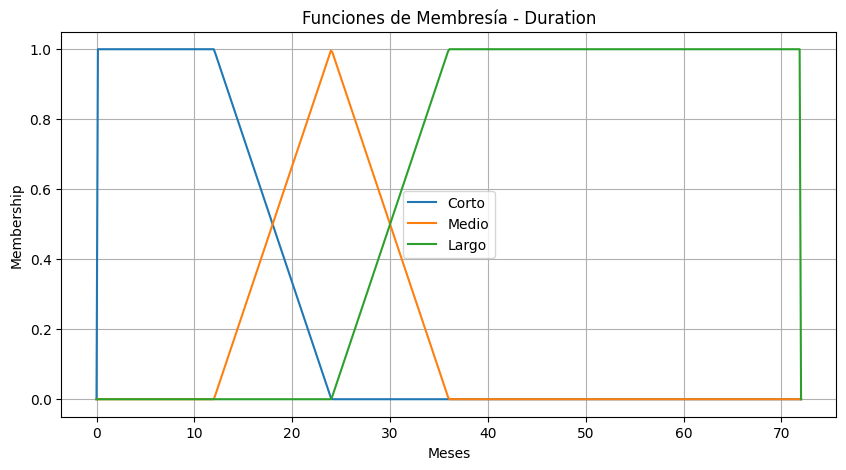

In [194]:
x = np.linspace(0, 72, 500)

corto = [
    trapezoidal(v, 0, 0, 12, 24)
    for v in x
]

medio = [
    triangular(v, 12, 24, 36)
    for v in x
]

largo = [
    trapezoidal(v, 24, 36, 72, 72)
    for v in x
]


plt.figure(figsize=(10, 5))

plt.plot(x, corto, label="Corto")
plt.plot(x, medio, label="Medio")
plt.plot(x, largo, label="Largo")

plt.title("Funciones de Membresía - Duration")
plt.xlabel("Meses")
plt.ylabel("Membership")

plt.legend()
plt.grid()

plt.show()

Credit Amount:

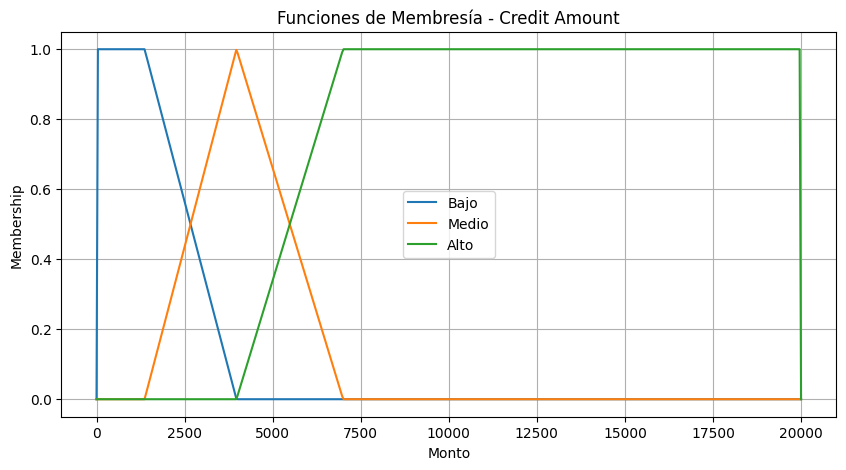

In [195]:
x = np.linspace(0, 20000, 500)

bajo = [
    trapezoidal(v, 0, 0, 1365, 3973)
    for v in x
]

medio = [
    triangular(v, 1365, 3973, 7000)
    for v in x
]

alto = [
    trapezoidal(v, 3973, 7000, 20000, 20000)
    for v in x
]


plt.figure(figsize=(10, 5))

plt.plot(x, bajo, label="Bajo")
plt.plot(x, medio, label="Medio")
plt.plot(x, alto, label="Alto")

plt.title("Funciones de Membresía - Credit Amount")
plt.xlabel("Monto")
plt.ylabel("Membership")

plt.legend()
plt.grid()

plt.show()

Las otras variables son categoricas y binarias, asi que no se pueden graficar igual

## Conclusiones:

Desempeño general

Los tres sistemas difusos obtuvieron desempeños relativamente similares, con accuracies cercanas al 56–59%. Los modelos Mamdani y Takagi-Sugeno alcanzaron el mejor desempeño general con una accuracy de 0.588, mientras que Tsukamoto presentó un rendimiento ligeramente inferior con 0.558.

Las métricas de precision, recall y F1-score fueron malas en los tres modelos, indicando que el sistema tiene capacidad limitada para identificar correctamente clientes de alto riesgo. Esto es esperable debido a que:

- las reglas fueron diseñadas manualmente,
- se utilizó un conjunto reducido de variables,
- no hubo optimización automática de memberships ni entrenamiento supervisado.

Además, el problema de riesgo crediticio posee relaciones no lineales complejas que difícilmente pueden ser capturadas completamente mediante una base pequeña de reglas heurísticas.

Comparación entre modelos
### Modelo Mamdani

El sistema Mamdani obtuvo:

Accuracy: 0.588
F1-score: 0.342

Este modelo mostró un comportamiento relativamente estable e interpretable. Debido a que Mamdani utiliza conjuntos difusos completos en la salida y posteriormente realiza defuzzificación, el sistema conserva una representación lingüística clara del riesgo.

La principal ventaja observada fue:

- interpretabilidad alta,
- facilidad para analizar reglas,
- comportamiento intuitivo.

Sin embargo, el proceso de defuzzificación introduce cierta pérdida de precisión numérica y puede generar salidas menos discriminativas entre clases.

### Modelo Takagi-Sugeno

El modelo Takagi-Sugeno presentó el mejor desempeño global:

Accuracy: 0.588
F1-score: 0.344

Aunque la mejora respecto a Mamdani es pequeña, Sugeno produjo resultados ligeramente más consistentes. Esto ocurre porque:
sus consecuentes son funciones numéricas directas,
evita procesos complejos de defuzzificación,
produce salidas más estables matemáticamente.
El weighted average utilizado en Sugeno suele generar superficies de decisión más suaves y menos sensibles al solapamiento de memberships.
Además, Sugeno es computacionalmente más eficiente y más apropiado para optimización automática o integración con técnicas híbridas como ANFIS.
La principal desventaja es:
menor interpretabilidad lingüística,
reglas menos intuitivas para usuarios no técnicos.

### Modelo Tsukamoto

El sistema Tsukamoto obtuvo el desempeño más bajo:

Accuracy: 0.558
F1-score: 0.322

Este comportamiento es consistente con la naturaleza del modelo. Tsukamoto requiere:
funciones monotónicas en los consecuentes,
inferencia individual por regla,
inversión de memberships para calcular salidas crisp.

Debido a estas restricciones:

El diseño del sistema fue más rígido,
la representación del riesgo medio fue menos natural,
las salidas tendieron a suavizarse excesivamente.
En este caso, el modelo probablemente perdió capacidad discriminativa entre clientes de riesgo medio y alto.
No obstante, Tsukamoto mantiene una ventaja importante:
las reglas producen salidas continuas dependientes del nivel de activación,
lo que permite respuestas más graduales y menos abruptas.

### Conclusión técnica

Los resultados muestran que los sistemas de inferencia difusa son capaces de modelar parcialmente el problema de riesgo crediticio utilizando reglas lingüísticas interpretables. Entre los modelos evaluados, Takagi-Sugeno presentó el mejor desempeño global debido a su estabilidad numérica y mecanismo de agregación directa. Mamdani ofreció mayor interpretabilidad, mientras que Tsukamoto mostró un comportamiento más conservador debido a las restricciones monotónicas de sus consecuentes. Pero honestamente, es necesario una mayor cantidad de variables y reglas para poder lograr modelar el problema correctamente.

Aunque las métricas obtenidas fueron moderadas, el estudio demuestra la viabilidad de utilizar lógica difusa para modelar problemas financieros con incertidumbre y conocimiento experto. El desempeño podría mejorarse mediante optimización automática de memberships, expansión de la base de reglas y utilización de sistemas neuro-difusos híbridos.